<a href="https://colab.research.google.com/github/Adityabehl/ML_Learning/blob/main/Multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving Dataset_2_fertilizer.csv to Dataset_2_fertilizer.csv
Saving Dataset_1_watermelon.csv to Dataset_1_watermelon.csv
Uploaded file: Dataset_2_fertilizer.csv
Uploaded file: Dataset_1_watermelon.csv


Watermelon Dataset:


,Year,Element,Value,Item
0,2000,Area harvested,45000.00,Watermelon
1,2001,Area harvested,46425.31,Watermelon
2,2002,Area harvested,47709.77,Watermelon
3,2003,Area harvested,48746.99,Watermelon
4,2004,Area harvested,49491.16,Watermelon



Fertilizer Dataset:


,Year,Element,Value,Item
0,2000,Fertilizer use,94.00,Fertilizer
1,2001,Fertilizer use,96.71,Fertilizer
2,2002,Fertilizer use,98.56,Fertilizer
3,2003,Fertilizer use,99.88,Fertilizer
4,2004,Fertilizer use,101.14,Fertilizer



Final Merged Dataset:


,Year,Area,Yield,Fertilizer
0,2000,45000.00,14500.00,94.00
1,2001,46425.31,15755.62,96.71
2,2002,47709.77,16619.62,98.56
3,2003,48746.99,16937.92,99.88
4,2004,49491.16,16887.46,101.14



Multiple Linear Regression Model
Intercept: -9634.984194372582
Area Coefficient: 0.32510313746173924
Fertilizer Coefficient: 105.46351022965081

Equation:
Yield = -9634.9842 + (0.3251 × Area) + (105.4635 × Fertilizer)

Mean Squared Error: 460627.11870792985

Actual vs Predicted Yield:


,Year,Actual Yield,Predicted Yield
0,2000,14500.00,14908.226953
1,2001,15755.62,15657.405819
2,2002,16619.62,16270.095288
3,2003,16937.92,16746.510598
4,2004,16887.46,17121.326623
5,2005,16868.88,17451.473497
6,2006,17263.45,17806.715774
7,2007,18201.86,18250.782131
8,2008,19484.89,18826.434682
9,2009,20704.30,19540.812675


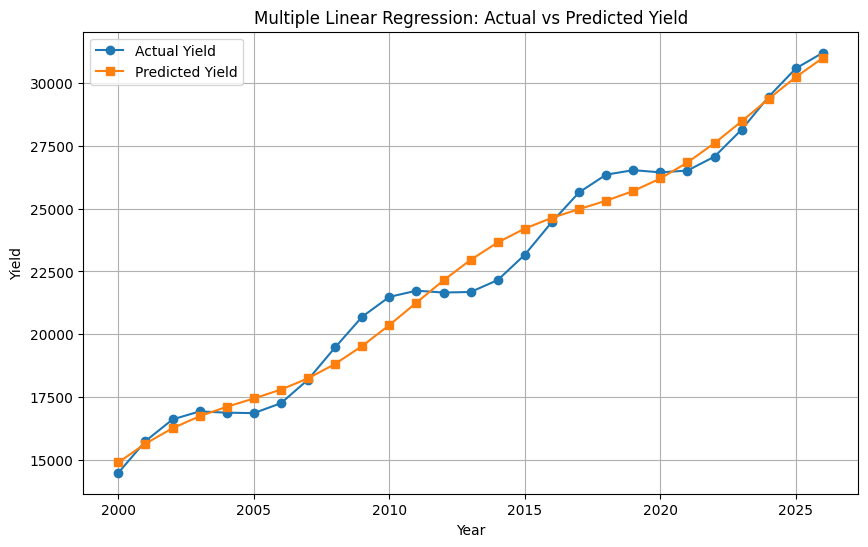

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD BOTH DATASETS
# ==========================================

watermelon_df = pd.read_csv("Dataset_1_watermelon.csv")
fertilizer_df = pd.read_csv("Dataset_2_fertilizer.csv")

print("Watermelon Dataset:")
display(watermelon_df.head())

print("\nFertilizer Dataset:")
display(fertilizer_df.head())


# ==========================================
# 2. SEPARATE AREA AND YIELD DATA
# ==========================================

area_data = watermelon_df[
    watermelon_df["Element"] == "Area harvested"
][["Year", "Value"]].copy()

area_data.rename(
    columns={"Value": "Area"},
    inplace=True
)


yield_data = watermelon_df[
    watermelon_df["Element"] == "Yield"
][["Year", "Value"]].copy()

yield_data.rename(
    columns={"Value": "Yield"},
    inplace=True
)


# ==========================================
# 3. PREPARE FERTILIZER DATA
# ==========================================

fertilizer_data = fertilizer_df[
    ["Year", "Value"]
].copy()

fertilizer_data.rename(
    columns={"Value": "Fertilizer"},
    inplace=True
)


# ==========================================
# 4. MERGE ALL DATASETS USING YEAR
# ==========================================

data = pd.merge(
    area_data,
    yield_data,
    on="Year"
)

data = pd.merge(
    data,
    fertilizer_data,
    on="Year"
)


print("\nFinal Merged Dataset:")
display(data.head())


# ==========================================
# 5. PREPARE INPUT AND OUTPUT
# ==========================================

# X = Independent Variables
X = data[["Area", "Fertilizer"]].to_numpy()

# y = Dependent Variable
y = data["Yield"].to_numpy()


# ==========================================
# 6. ADD BIAS COLUMN
# ==========================================

X_bias = np.c_[
    np.ones(X.shape[0]),
    X
]


# ==========================================
# 7. TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ==========================================

# Calculate coefficients using Normal Equation
coefficients = np.linalg.inv(
    X_bias.T @ X_bias
) @ X_bias.T @ y


intercept = coefficients[0]

area_coefficient = coefficients[1]

fertilizer_coefficient = coefficients[2]


# ==========================================
# 8. DISPLAY MODEL EQUATION
# ==========================================

print("\nMultiple Linear Regression Model")

print("Intercept:", intercept)

print("Area Coefficient:", area_coefficient)

print("Fertilizer Coefficient:", fertilizer_coefficient)


print("\nEquation:")

print(
    f"Yield = {intercept:.4f} "
    f"+ ({area_coefficient:.4f} × Area) "
    f"+ ({fertilizer_coefficient:.4f} × Fertilizer)"
)


# ==========================================
# 9. MAKE PREDICTIONS
# ==========================================

predicted_y = X_bias @ coefficients


# ==========================================
# 10. CALCULATE MEAN SQUARED ERROR
# ==========================================

mse = np.mean(
    (y - predicted_y) ** 2
)

print("\nMean Squared Error:", mse)


# ==========================================
# 11. SHOW ACTUAL VS PREDICTED VALUES
# ==========================================

results = pd.DataFrame({
    "Year": data["Year"],
    "Actual Yield": y,
    "Predicted Yield": predicted_y
})

print("\nActual vs Predicted Yield:")

display(results)


# ==========================================
# 12. VISUALIZE RESULTS
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    data["Year"],
    y,
    marker="o",
    label="Actual Yield"
)

plt.plot(
    data["Year"],
    predicted_y,
    marker="s",
    label="Predicted Yield"
)

plt.xlabel("Year")

plt.ylabel("Yield")

plt.title(
    "Multiple Linear Regression: Actual vs Predicted Yield"
)

plt.legend()

plt.grid()

plt.show()